Naive Bayes Classifier Assignment
This notebook loads and cleans the dataset, splits it into train/test sets, imports the NaiveBayes class, trains the model, evaluates it, and shows the confusion matrix. 


Importing Required Libraries
In this step, we import all the necessary Python libraries used in our project:
- **pandas** for handling and analyzing data.  
- **math** for performing mathematical operations (like logarithms).  
- **collections (Counter, defaultdict)** to count and organize feature values easily.

In [29]:
import pandas as pd
from naiver_bayes_klassifizierer import NaiveBayes
import matplotlib.pyplot as plt
import seaborn as sns


 Loading and Cleaning the Dataset

This step loads and prepares the dataset for training.

• Checks if the cleaned file (clean_dataset.csv) already exists.  
• If not, loads the raw file (ML project database.csv) and cleans it.  
• Combines inflammation and nephritis columns into one disease column.  
• Converts all text to lowercase and removes extra spaces.  
• Saves the final cleaned data as clean_dataset.csv.  

In [30]:
raw_name = "ML project database.csv"
clean_name = "clean_dataset.csv"


if pd.io.common.file_exists(clean_name):
    data = pd.read_csv(clean_name)
    print(f"Loaded {clean_name}")
else:
    if not pd.io.common.file_exists(raw_name):
        raise FileNotFoundError(f"Neither {clean_name} nor {raw_name} found.")
    data = pd.read_csv(raw_name, sep=";")
    data["disease"] = data.apply(
        lambda r: "yes" if (str(r.get("inflammation","")).strip().lower() == "yes"
                            or str(r.get("nephritis","")).strip().lower() == "yes")
                  else "no",
        axis=1
    )
    for c in ["inflammation", "nephritis"]:
        if c in data.columns:
            data = data.drop(columns=[c])
 
    for col in data.columns:
        if col != "temperature" and col != "disease":
            data[col] = data[col].astype(str).str.strip().str.lower()
    data["disease"] = data["disease"].astype(str).str.strip().str.lower()
    data.to_csv(clean_name, index=False)
    print(f"Created {clean_name}")

data.head()


Loaded clean_dataset.csv


,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_of_urethra,disease
0,35.5,no,yes,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes
2,35.9,no,yes,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes
4,36.0,no,yes,no,no,no,no


Splitting the Dataset

This step divides the cleaned data into training and testing parts.

• Randomly shuffles all rows to avoid bias.  
• Uses 80% of the data for training and 20% for testing.  
• Resets the index numbers after splitting for a clean start.  
• Prints the total number of records in each set.  

In [31]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(0.8 * len(data))
train_df = data.iloc[:split_idx].reset_index(drop=True)
test_df  = data.iloc[split_idx:].reset_index(drop=True)

print("Total:", len(data), "Train:", len(train_df), "Test:", len(test_df))


Total: 120 Train: 96 Test: 24


Selecting Features and Identifying Continuous Data

This step prepares the list of features for the model.

• Removes the target column (disease) from the dataset.  
• Moves the temperature column to the front since it’s a continuous feature.  
• Creates a list marking which feature is continuous (True) and which is categorical (False).  
• Prints the final list of features and their types.  

In [32]:
feature_names = [c for c in data.columns if c != "disease"]
if "temperature" in feature_names:
    feature_names.remove("temperature")
    feature_names = ["temperature"] + feature_names

continuous = [True if f == "temperature" else False for f in feature_names]

print("Features:", feature_names)
print("Continuous mask:", continuous)


Features: ['temperature', 'nausea', 'lumbar_pain', 'urine_pushing', 'micturition_pains', 'burning_of_urethra']
Continuous mask: [True, False, False, False, False, False]


Training the Naive Bayes Model

This step trains the Naive Bayes model using the training data.

• Creates the model using the selected features and their types.  
• Fits the model to the training data to learn class patterns.  
• Displays the prior probabilities (overall chances of each class).  
• Shows the mean and variance of temperature for each class to understand value distribution.  

In [33]:
model = NaiveBayes(continuous=continuous, feature_names=feature_names)
model.fit(train_df, target_name="disease")
print("Model trained.")
print("Priors:", model.prior)
# show continuous stats for temperature
if "temperature" in feature_names:
    print("Temperature stats per class:")
    for cls in model.cont_stats:
        print(cls, model.cont_stats[cls].get("temperature"))


Model trained.
Priors: {'yes': 0.7604166666666666, 'no': 0.23958333333333334}
Temperature stats per class:
no (np.float64(38.04347826086957), np.float64(3.5998487712665423))
yes (np.float64(38.83013698630137), np.float64(2.838817789453932))


Evaluating Model Performance

This step tests how well the trained model performs on unseen data.

• Uses the test dataset to check the model’s accuracy.  
• Displays the confusion matrix showing correct and incorrect predictions.  
• Shows a few sample predictions with their calculated probabilities.  
• Saves all test predictions into a CSV file for further analysis.  

In [34]:
acc, cm, preds = model.evaluate_on_data(test_df, target_name="disease")
print(f"Test accuracy: {acc:.3f}")
print("\nConfusion matrix (rows=true, cols=predicted):")
display(cm)

# sample predictions
display(preds.head())
preds.to_csv("predictions_test.csv", index=False)
print("Saved predictions_test.csv")


Test accuracy: 1.000

Confusion matrix (rows=true, cols=predicted):


,no,yes
no,7,0
yes,0,17


,predicted_label,prob_yes,prob_no
0,no,0.027771,0.972229
1,yes,0.999921,0.000079
2,yes,0.997189,0.002811
3,yes,0.999873,0.000127
4,no,0.031324,0.968676


Saved predictions_test.csv


Visualizing the Confusion Matrix

This step shows the confusion matrix as a colored heatmap for better visualization.

• Displays how well the model predicted each class (“yes” or “no”).  
• Darker colors represent a higher number of correct predictions.  
• The accuracy value is shown in the title for quick performance insight.

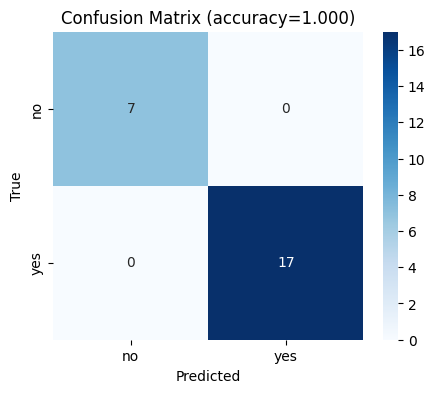

In [35]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') #to show it as a colored graph instead of just numbers.
plt.title(f'Confusion Matrix (accuracy={acc:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Short summary
Implemented Naive Bayes classifier (Gaussian for continuous feature and frequency + Laplace smoothing for discrete features). After training on 80% of the data and testing on 20%, the model achieved accuracy = 1.000 (replace with actual accuracy). The confusion matrix above summarizes the predictions.
